# PS-S06E06: Model Stacking

This notebook tackles the [**Playground Series – Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`GALAXY`, `QSO`, `STAR`) for the `class` target, based on features describing the position, light intensity for various spectrums, and other features of the observation.

## Ensemble Strategy: Stacking with a Logistic Meta-Model

Blending (weighted averaging) can fail when one model is dominant or when models are highly correlated. Stacking treats ensembling as a supervised learning problem: we train a small meta-model to combine base model probabilities.

A practical advantage is that a weaker model can still help if it is *differently wrong*—the meta-model can learn when to trust it.


## Install Needed Packages

In [1]:
import os
import glob
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import cross_val_predict, StratifiedKFold

from ps_s06e06_experiment_setup import ExperimentSetup
from ps_s06e06_model_visualizer import ModelVisualizer

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
setup = ExperimentSetup()

seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'class'

Random seed set to: 10301
Warnings suppressed.


In [3]:
# Load ground truth labels
training_df = setup.read_dataset('training')

# Encode target labels
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}
y_true = training_df[TARGET].map(target_mapping).astype(int)

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  is_original  
0             M      Red_Sequence  GALAXY        False  
1             M      Red_Sequence  GALAXY        False  
2           O/B        Blue_Cloud     QSO        False  
3             M      Red_Sequence  GALAXY        False  
4             M      Red_Sequence  GALAXY        False  


In [4]:
submission_df = setup.read_dataset('submission')

## Loading OOF and Test Probabilities

We load the out-of-fold (OOF) and test-set **probabilities** generated by individual model notebooks.

Expected file naming:
- `*_oof_probs.csv` contains columns: `id`, one probability column (e.g. `prob_xgb`), and optionally `target`
- `*_test_probs.csv` contains columns: `id` and one probability column

All files should share the same `id` values as the competition datasets.


In [5]:
oof_files = []
test_files = []

# Local convention: predictions stored under predictions/s06e06/
# Kaggle convention: mount dataset input that contains predictions/
if setup.running_in_kaggle():
    pred_dir = '/kaggle/input/notebooks/stephentarter/ps-s06e06-*/predictions'
else:
    pred_dir = 'predictions'

oof_files = sorted(glob.glob(f'{pred_dir}/*_oof_probs.csv'))
test_files = sorted(glob.glob(f'{pred_dir}/*_test_probs.csv'))

print(f'Found {len(oof_files)} OOF files and {len(test_files)} Test files.')
if len(oof_files) > 0:
    print('OOF files:')
    for f in oof_files:
        print(' -', os.path.basename(f))
if len(test_files) > 0:
    print('Test files:')
    for f in test_files:
        print(' -', os.path.basename(f))

Found 4 OOF files and 4 Test files.
OOF files:
 - catboost_oof_probs.csv
 - lgb_oof_probs.csv
 - nn_tabular_resnet_oof_probs.csv
 - xgb_oof_probs.csv
Test files:
 - catboost_test_probs.csv
 - lgb_test_probs.csv
 - nn_tabular_resnet_test_probs.csv
 - xgb_test_probs.csv


In [6]:
# setup to load and merge probabilities
def load_probs(file_list, index_col='id'):
    df_list = []
    for file in file_list:
        base = os.path.basename(file)
        model_name = (
            base.replace('_oof_probs.csv', '')
                .replace('_test_probs.csv', '')
        )

        df = pd.read_csv(file)

        # Identify the probability column (exclude id/target)
        ignore = {'id', 'target', TARGET}
        prob_cols = [c for c in df.columns if c not in ignore]
        
        # Rename columns to include model name to avoid collisions
        # e.g., 'catboost_prob_low', 'catboost_prob_medium', etc.
        rename_map = {c: f"{model_name}_{c}" for c in prob_cols}

        # Set index and keep only the renamed prob columns
        subset = df.set_index(index_col).rename(columns=rename_map)[list(rename_map.values())]
        df_list.append(subset)

    # Join all models side-by-side
    return pd.concat(df_list, axis=1)

Missing test rows per model:
None

OOF Shape: (577347, 12)
Test Shape: (247435, 12)


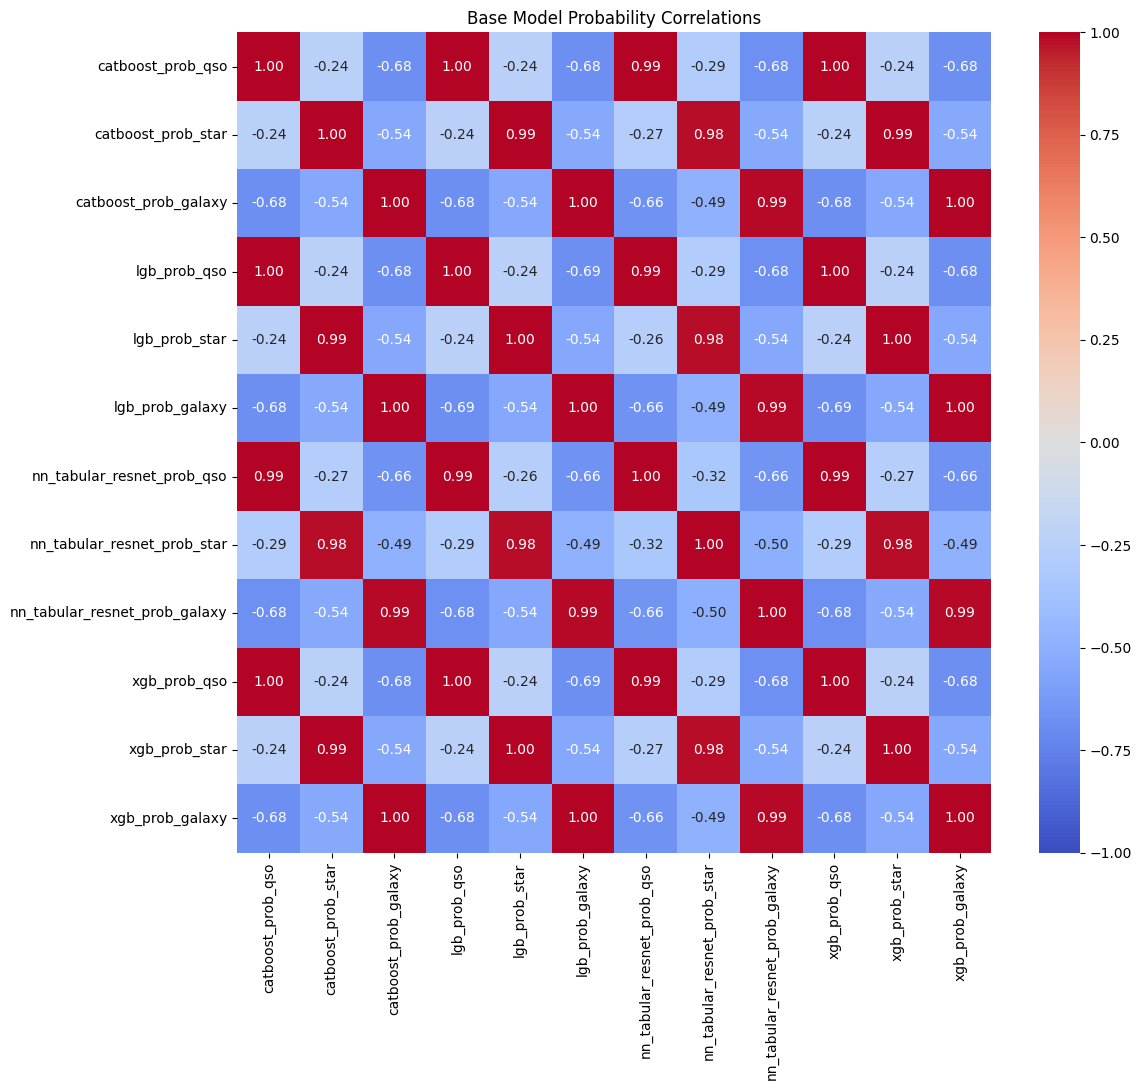

In [7]:
# Create DataFrames
oof_df = load_probs(oof_files)
test_df = load_probs(test_files)

# Report missing values in OOF data before dropping
raw_oof_len = len(oof_df)
missing_oof = oof_df.isna().sum().sort_values(ascending=False)
if missing_oof.any():
    print("Missing OOF values per column:")
    print(missing_oof[missing_oof > 0])

# Look for missing rows in test data
missing_by_model = test_df.isna().sum().sort_values(ascending=False)
print("Missing test rows per model:")
print(missing_by_model[missing_by_model > 0] if missing_by_model.any() else "None")

# Create an id-indexed label series
y_by_id = pd.Series(y_true.values, index=training_df['id'].values)

# Keep only rows where all models have OOF probabilities
oof_df = oof_df.sort_index().dropna(axis=0)
n_dropped = raw_oof_len - len(oof_df)
if n_dropped > 0:
    print(f"WARNING: Dropped {n_dropped} OOF rows with missing predictions across models.")
y_true_aligned = y_by_id.loc[oof_df.index].values

# Align test_df to submission id order — critical for correct label assignment
test_df = test_df.reindex(submission_df['id'].values)

# Restrict to columns present in both OOF and test (defensive against file mismatches)
common_cols = [c for c in oof_df.columns if c in test_df.columns]
if len(common_cols) < len(oof_df.columns):
    dropped_cols = set(oof_df.columns) - set(common_cols)
    print(f"WARNING: Dropping {len(dropped_cols)} columns not present in test_df: {dropped_cols}")
oof_df  = oof_df[common_cols]
test_df = test_df[common_cols]

print(f'\nOOF Shape: {oof_df.shape}')
print(f'Test Shape: {test_df.shape}')

# Probability correlation heatmap across all class columns
n_cols = len(oof_df.columns)
fig_size = max(10, n_cols)
plt.figure(figsize=(fig_size, fig_size - 1))
sns.heatmap(oof_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Base Model Probability Correlations')
plt.tight_layout()
plt.show()


In [8]:
print('\nIndividual Model Balanced Accuracy (OOF):')
individual_scores = {}

# Sorted for deterministic ordering
model_names = sorted(set([c.split('_prob_')[0] for c in oof_df.columns]))

for model in model_names:
    cols = [f"{model}_prob_qso", f"{model}_prob_star", f"{model}_prob_galaxy"]
    preds = np.argmax(oof_df[cols].values, axis=1)
    score = balanced_accuracy_score(y_true_aligned, preds)
    individual_scores[model] = score
    print(f'{model:30}: {score:.6f}')

best_single_model = max(individual_scores, key=individual_scores.get)
print(f'\nBest single model: {best_single_model} ({individual_scores[best_single_model]:.6f})')



Individual Model Balanced Accuracy (OOF):
catboost                      : 0.964600
lgb                           : 0.963213
nn_tabular_resnet             : 0.956607
xgb                           : 0.964794

Best single model: xgb (0.964794)


## Stacking Optimization: Logistic Regression Meta-Model

We train a second-level meta-model on the base models' **OOF probabilities**.

* **Features (X):** OOF probabilities from each base model.
* **Target (y):** true class label (0=QSO, 1=STAR, 2=GALAXY).
* 
We use **logistic regression with L2 regularization** as the meta-model. It is fast, stable under correlation, and outputs a valid probability in [0, 1].
The regularization strength is tuned via internal cross-validation.


In [9]:
# ==========================================
# STACKING STRATEGY (Meta-Model)
# ==========================================

print('Preparing stacking data...')

# model_cols already restricted to columns present in both oof_df and test_df
model_cols = list(oof_df.columns)
print('Stacking feature columns:', model_cols)

X_stack      = oof_df[model_cols].to_numpy(dtype=np.float64)
X_test_stack = test_df[model_cols].to_numpy(dtype=np.float64)
y_stack = y_true_aligned

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

meta_model = lgb.LGBMClassifier(
    objective='multiclass',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,          # keep shallow — only 12 input features, overfitting risk is real
    num_leaves=7,         # 2^3 - 1, consistent with max_depth=3
    min_child_samples=100,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    class_weight='balanced',
    random_state=seed,
    n_jobs=-1,
    verbosity=-1,
)

# cross_val_predict with n_jobs=1 to avoid parallelism contention:
# LightGBM already uses n_jobs=-1 internally; letting sklearn also
# fork outer CV jobs causes resource contention on Kaggle.
oof_meta_probs = cross_val_predict(
    meta_model, X_stack, y_stack,
    cv=cv,
    method='predict_proba',
    n_jobs=1,
)
oof_meta_preds = np.argmax(oof_meta_probs, axis=1)

score_meta = balanced_accuracy_score(y_stack, oof_meta_preds)
print(f'Meta-model OOF Balanced Accuracy: {score_meta:.6f}')

# Final fit on ALL training data for test-set predictions
meta_model.fit(X_stack, y_stack)

# Feature importance — which base model probability columns the meta-model trusts most
imp = pd.Series(meta_model.feature_importances_, index=model_cols).sort_values(ascending=False)
print('\nMeta-model feature importances:')
print(imp.to_string())

# Save OOF meta-probabilities for higher-level ensembling (blend-of-stack)
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)
prob_cols = ['prob_qso', 'prob_star', 'prob_galaxy']
oof_meta_df = pd.DataFrame(oof_meta_probs, columns=prob_cols, index=oof_df.index)
oof_meta_df.index.name = 'id'
oof_meta_df['target'] = y_stack
oof_meta_df = oof_meta_df.reset_index()[[ 'id', 'target'] + prob_cols]
oof_meta_df.to_csv(f'{output_dir}/stacking_oof_probs.csv', index=False)
print(f'Saved OOF meta-probabilities to {output_dir}/stacking_oof_probs.csv')


Preparing stacking data...
Stacking feature columns: ['catboost_prob_qso', 'catboost_prob_star', 'catboost_prob_galaxy', 'lgb_prob_qso', 'lgb_prob_star', 'lgb_prob_galaxy', 'nn_tabular_resnet_prob_qso', 'nn_tabular_resnet_prob_star', 'nn_tabular_resnet_prob_galaxy', 'xgb_prob_qso', 'xgb_prob_star', 'xgb_prob_galaxy']
Meta-model OOF Balanced Accuracy: 0.965242

Meta-model feature importances:
xgb_prob_galaxy                  943
catboost_prob_star               860
catboost_prob_galaxy             850
xgb_prob_star                    793
catboost_prob_qso                774
nn_tabular_resnet_prob_qso       763
nn_tabular_resnet_prob_galaxy    757
lgb_prob_qso                     743
lgb_prob_galaxy                  660
xgb_prob_qso                     612
lgb_prob_star                    591
nn_tabular_resnet_prob_star      528
Saved OOF meta-probabilities to predictions/stacking_oof_probs.csv


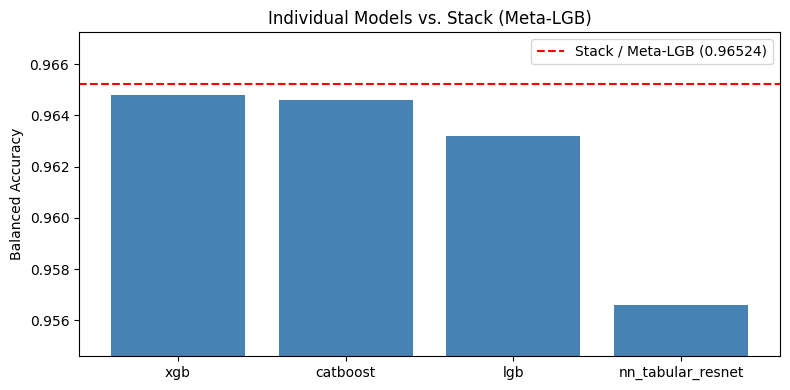

In [10]:
# Sort models by score descending for a cleaner chart
sorted_scores = dict(sorted(individual_scores.items(), key=lambda x: -x[1]))

plt.figure(figsize=(max(8, len(sorted_scores) * 1.5), 4))
bars = plt.bar(sorted_scores.keys(), sorted_scores.values(), color='steelblue')
plt.axhline(score_meta, color='red', linestyle='--',
            label=f'Stack / Meta-LGB ({score_meta:.5f})')
plt.ylabel('Balanced Accuracy')
y_min = min(min(sorted_scores.values()), score_meta) - 0.002
y_max = max(max(sorted_scores.values()), score_meta) + 0.002
plt.ylim(y_min, y_max)
plt.legend()
plt.title('Individual Models vs. Stack (Meta-LGB)')
plt.tight_layout()
plt.show()


## Final Ensemble & Submission

We generate test-set probabilities by applying the trained meta-model to the matrix of base-model test probabilities.
The submission file uses the competition's sample submission schema.


In [11]:
# Generate test probabilities from the fitted meta-model
# test_df was already reindexed to submission_df['id'] order in cell 11,
# so X_test_stack rows correspond 1-to-1 with sub rows.
sub = submission_df.copy()
target_col = [c for c in sub.columns if c != 'id'][0]
reverse_mapping = {v: k for k, v in target_mapping.items()}

test_meta_probs = meta_model.predict_proba(X_test_stack)
test_meta_pred  = np.argmax(test_meta_probs, axis=1)

# Assign directly — no pd.Series reindex needed since row order already matches
sub[target_col] = [reverse_mapping[p] for p in test_meta_pred]

sub.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

print('\nSUBMISSION')
print('==========')
print(sub.head(10))

print('\nPredicted Class Distribution:')
print(sub[target_col].value_counts(normalize=True).sort_index())

# Also save test meta-probabilities for higher-level ensembling
test_meta_df = pd.DataFrame(test_meta_probs, columns=prob_cols)
test_meta_df.insert(0, 'id', submission_df['id'].values)
test_meta_df.to_csv(f'{output_dir}/stacking_test_probs.csv', index=False)
print(f'Saved test meta-probabilities to {output_dir}/stacking_test_probs.csv')


Saved: submission.csv

SUBMISSION
       id   class
0  577347  GALAXY
1  577348  GALAXY
2  577349  GALAXY
3  577350    STAR
4  577351  GALAXY
5  577352  GALAXY
6  577353  GALAXY
7  577354    STAR
8  577355  GALAXY
9  577356  GALAXY

Predicted Class Distribution:
class
GALAXY   0.631
QSO      0.208
STAR     0.161
Name: proportion, dtype: float64
Saved test meta-probabilities to predictions/stacking_test_probs.csv
